# 02. Training

## 1. Overview

This notebook introduces the training workflow for MRI super-resolution (SR) with residual learning. Each sample contains a low-resolution input (`src`) and a high-resolution target (`dst`). Instead of predicting the full high-resolution image from scratch, the model predicts a residual image, which is later added back to the upsampled input.

UNet, DDPM, and Flow Matching use the same tutorial framework: a U-Net-style backbone, the same data pipeline, and PyTorch Lightning for training. Their main difference is the learning objective. UNet directly regresses the residual, DDPM learns a denoising process with iterative sampling, and Flow Matching learns a velocity field for ODE-style sampling.

Notebook roadmap:
1. Review the residual-learning training target and the differences between the three model families.
2. Run a minimal 2D UNet demo to understand the core training loop.
3. Switch to 2.5D data and launch YAML-based training for UNet, DDPM, and Flow Matching.

## 2. Training a Minimal 2D UNet Demo

We begin with a small 2D UNet demo before moving to the full 2.5D configurations. This demo exposes the essential training components: path setup, random seed control, config-driven object creation, checkpointing, logging, and the PyTorch Lightning training loop.

The goal of this section is not to obtain the best SR result, but to make the workflow easy to inspect before using larger YAML configs.

### 2.1 Set Up Imports, Paths, Logging, and the Random Seed

In [1]:
from pathlib import Path

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger

from utils import instantiate_from_config, plot_csvlogger_curves

W0507 20:43:17.448000 27276 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Use this setup cell to prepare a reproducible experiment environment:
- Detect the project root from the current working directory.
- Define the data, checkpoint, and log directories.
- Create output folders if they do not already exist.
- Fix the random seed with `pl.seed_everything`.

Keeping these paths and seeds consistent makes different runs easier to compare.

In [2]:
# Resolve project root robustly from current working directory.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "tutorial" else cwd

# These are absolute paths under project root.
DATA_DIR = (PROJECT_ROOT / "data").resolve()
CKPT_ROOT = (PROJECT_ROOT / "checkpoints").resolve()
LOG_ROOT = (PROJECT_ROOT / "logs").resolve()
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_ROOT.mkdir(parents=True, exist_ok=True)

pl.seed_everything(24, workers=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_ROOT:", CKPT_ROOT)
print("LOG_ROOT:", LOG_ROOT)

Seed set to 24


PROJECT_ROOT: E:\MRI_SR_Tutorial
DATA_DIR: E:\MRI_SR_Tutorial\data
CKPT_ROOT: E:\MRI_SR_Tutorial\checkpoints
LOG_ROOT: E:\MRI_SR_Tutorial\logs


### 2.2 Build a Minimal In-Notebook Config

Production runs use YAML files under `config/`. For the demo, we keep a small config dictionary inside the notebook so the key settings are visible in one place: model parameters, data loading parameters, trainer options, and logging settings.

This also demonstrates the config-driven style used throughout the tutorial. The same pattern will later allow us to switch models or datasets by editing the config instead of rewriting the training loop.


In [3]:
demo_cfg = {
    "model": {
        "target": "model.unet.UNet",
        "params": {
            "in_channels": 1,
            "out_channels": 1,
            "unet_channels": (16, 32, 64, 96),
            "initial_lr": 1e-4,
        },
    },
    "data": {
        "target": "dataset.SRSliceDataModule",
        "params": {
            "data_dir": str(DATA_DIR),
            "batch_size": 8,
            "num_workers": 4,
            "slice_axis": 1,
            "slice_nums": 32,
            "cache_mode": "memmap",
        },
    },
    "trainer": {
        "devices": [0],
        "accelerator": "auto",
        "precision": "16-mixed",
        "max_epochs": 2,
        "check_val_every_n_epoch": 1,
        "strategy": "auto",
        "ckpt_dir": str(CKPT_ROOT / "UNet_demo"),
        "ckpt_monitor": "val/loss",
        "mode": "min",
    },
    "log": {
        "project": "MRI_SR_Tutorial",
        "name": "UNet_demo",
        "log_dir": str(LOG_ROOT),
    },
    "seed": 24,
}

### 2.3 Instantiate the DataModule and Model

This cell converts the config entries into actual Python objects using `instantiate_from_config`. With this pattern, you can replace a dataset or model by changing the `target` string and its `params`, while keeping the surrounding training code unchanged.

We also inspect one training batch to verify that the expected keys, such as `src`, `dst`, and `residual`, are present and have reasonable tensor shapes. This is a useful sanity check before starting training.


In [4]:
dm = instantiate_from_config(
    model_name=demo_cfg["data"]["target"],
    **demo_cfg["data"]["params"],
)
model = instantiate_from_config(
    model_name=demo_cfg["model"]["target"],
    **demo_cfg["model"]["params"],
)

print(type(dm))
print(type(model))

# Inspect one training batch shape.
dm.setup("fit")
train_batch = next(iter(dm.train_dataloader()))
for key in ["src", "dst", "residual"]:
    if key in train_batch:
        print(f"{key}: {tuple(train_batch[key].shape)}")

<class 'dataset.SRSliceDataModule'>
<class 'model.unet.UNet'>
src: (8, 1, 224, 224)
dst: (8, 1, 224, 224)
residual: (8, 1, 224, 224)


### 2.4 Add Checkpointing and Metric Logging

Next, we add standard training utilities:
- `ModelCheckpoint` saves the best checkpoint according to the selected validation metric.
- `LearningRateMonitor` records learning-rate changes during training.
- `CSVLogger` writes metrics to `metrics.csv`, which can be plotted later for quick comparison.

Together, these utilities make each run easier to trace, compare, and resume.


In [5]:
ckpt_monitor = demo_cfg["trainer"]["ckpt_monitor"]
safe_name = ckpt_monitor.replace("/", "_")
filename = f"epoch_{{epoch:03d}}_{safe_name}_{{{ckpt_monitor}:.4f}}"

ckpt_cb = ModelCheckpoint(
    dirpath=demo_cfg["trainer"]["ckpt_dir"],
    filename=filename,
    auto_insert_metric_name=False,
    monitor=ckpt_monitor,
    mode=demo_cfg["trainer"].get("mode", "min"),
    save_last=True,
    save_top_k=1,
)
lr_cb = LearningRateMonitor(logging_interval="step")

logger = CSVLogger(
    save_dir=demo_cfg["log"]["log_dir"],
    name=demo_cfg["log"]["name"],
)

print("Checkpoint dir:", demo_cfg["trainer"]["ckpt_dir"])

Checkpoint dir: E:\MRI_SR_Tutorial\checkpoints\UNet_demo


### 2.5 Build the Trainer and Run the Demo

This cell creates a PyTorch Lightning `Trainer` and starts training with `trainer.fit(model, datamodule=dm)`. Lightning handles the training loop, validation loop, metric logging, and checkpoint callbacks.

After training, the notebook prints the best checkpoint path and plots the CSVLogger curves for a quick diagnostic check. If GPU memory is limited, reduce `batch_size` first. If that is still not enough, reduce `unet_channels` or use a smaller training subset.


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
C:\Users\jialin-li\.conda\envs\mri_sr\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory E:\MRI_SR_Tutorial\checkpoints\UNet_demo exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate numbe

Output()

`Trainer.fit` stopped: `max_epochs=2` reached.


Best checkpoint: E:\MRI_SR_Tutorial\checkpoints\UNet_demo\epoch_001_val_loss_0.0104-v1.ckpt


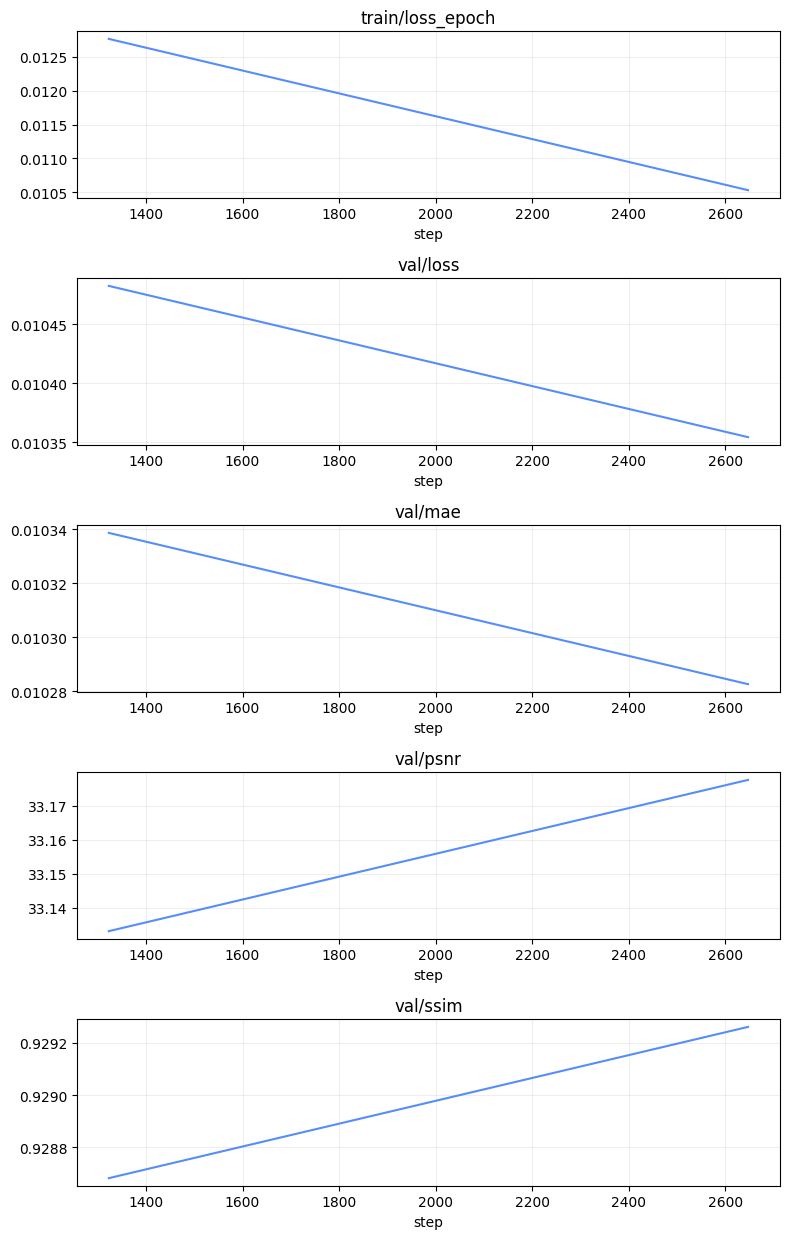

In [6]:
trainer = pl.Trainer(
    strategy=demo_cfg["trainer"].get("strategy", "auto"),
    devices=demo_cfg["trainer"]["devices"],
    accelerator=demo_cfg["trainer"].get("accelerator", "auto"),
    precision=demo_cfg["trainer"]["precision"],
    max_epochs=demo_cfg["trainer"]["max_epochs"],
    logger=logger,
    callbacks=[ckpt_cb, lr_cb],
    check_val_every_n_epoch=demo_cfg["trainer"].get("check_val_every_n_epoch", 1),
    use_distributed_sampler=True,
    enable_model_summary=False
)

trainer.fit(model, datamodule=dm)
print("Best checkpoint:", ckpt_cb.best_model_path)

# Plot demo curves from CSVLogger.
plot_csvlogger_curves(
    logger_root=Path(demo_cfg["log"]["log_dir"]) / demo_cfg["log"]["name"],
    metrics=["train/loss", "val/loss", "val/mae", "val/psnr", "val/ssim"],
)

## 3. Training from YAML Configs

After the minimal 2D demo, we move to YAML-based 2.5D training for all three model families. In 2.5D SR, neighboring slices provide anatomical context, while the model still predicts the high-resolution center slice or its residual. This is a practical compromise between simple 2D training and more memory-intensive 3D training.

All runs in this section use `TwoP5DSRSliceDataModule`, including the UNet baseline. Config files:
- `config/unet_2p5d.yaml`
- `config/ddpm_2p5d.yaml`
- `config/fm_2p5d.yaml`

The tutorial configs are intentionally lightweight: they use fewer slices, smaller models, and fewer epochs than a full research run. For serious experiments, you should increase the amount of training data and tune the model size, training length, and validation strategy.


### 3.1 Define a Reusable YAML Training Helper

This helper wraps the repeated setup steps for YAML-based experiments. It loads the config, resolves project-relative paths, sets the random seed, builds the DataModule and model, configures checkpointing and logging, launches training, and plots the logged curves.

In [7]:
import yaml


def _resolve_path_from_root(v: str, project_root: Path) -> str:
    p = Path(v)
    if not p.is_absolute():
        p = (project_root / p).resolve()
    return str(p)


def run_training_from_yaml(config_path: str):
    config_path = Path(config_path).resolve()
    project_root = config_path.parent.parent

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    # Resolve all root-relative paths from YAML into absolute paths.
    cfg["data"]["params"]["data_dir"] = _resolve_path_from_root(cfg["data"]["params"]["data_dir"], project_root)
    cfg["trainer"]["ckpt_dir"] = _resolve_path_from_root(cfg["trainer"]["ckpt_dir"], project_root)
    cfg["log"]["log_dir"] = _resolve_path_from_root(cfg["log"]["log_dir"], project_root)
    if "test_output_dir" in cfg:
        cfg["test_output_dir"] = _resolve_path_from_root(cfg["test_output_dir"], project_root)

    pl.seed_everything(cfg["seed"], workers=True)

    dm = instantiate_from_config(
        model_name=cfg["data"]["target"],
        **cfg["data"]["params"],
    )
    model = instantiate_from_config(
        model_name=cfg["model"]["target"],
        **cfg["model"]["params"],
    )

    ckpt_monitor = cfg["trainer"]["ckpt_monitor"]
    safe_name = ckpt_monitor.replace("/", "_")
    filename = f"epoch_{{epoch:03d}}_{safe_name}_{{{ckpt_monitor}:.4f}}"

    ckpt_cb = ModelCheckpoint(
        dirpath=cfg["trainer"]["ckpt_dir"],
        filename=filename,
        auto_insert_metric_name=False,
        monitor=ckpt_monitor,
        mode=cfg["trainer"].get("mode", "min"),
        save_last=True,
        save_top_k=3,
    )
    lr_cb = LearningRateMonitor(logging_interval="step")

    logger = CSVLogger(
        save_dir=cfg["log"]["log_dir"],
        name=cfg["log"]["name"],
    )

    trainer = pl.Trainer(
        strategy=cfg["trainer"].get("strategy", "auto"),
        devices=cfg["trainer"]["devices"],
        accelerator=cfg["trainer"].get("accelerator", "auto"),
        precision=cfg["trainer"].get("precision", "32-true"),
        max_epochs=cfg["trainer"]["max_epochs"],
        logger=logger,
        callbacks=[ckpt_cb, lr_cb],
        check_val_every_n_epoch=cfg["trainer"].get("check_val_every_n_epoch", 1),
        use_distributed_sampler=True,
        enable_model_summary=False
    )

    trainer.fit(model, datamodule=dm)
    print(f"[{cfg['log']['name']}] best checkpoint: {ckpt_cb.best_model_path}")

    plot_csvlogger_curves(
        logger_root=Path(cfg["log"]["log_dir"]) / cfg["log"]["name"],
    )

### 3.2 Train the 2.5D UNet

Run the cell below to train 2.5D UNet with `config/unet_2p5d.yaml`.

This process may take about 15 mins.

UNet directly predicts the residual image, so it serves as a fast and important deterministic baseline for the later generative models. Checkpoints and logs will be saved according to the paths defined in the YAML config.

Seed set to 24
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\jialin-li\.conda\envs\mri_sr\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory E:\MRI_SR_Tutorial\checkpoints\UNet_2p5d exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=15` reached.


[UNet_2p5d] best checkpoint: E:\MRI_SR_Tutorial\checkpoints\UNet_2p5d\epoch_009_val_loss_0.0082.ckpt


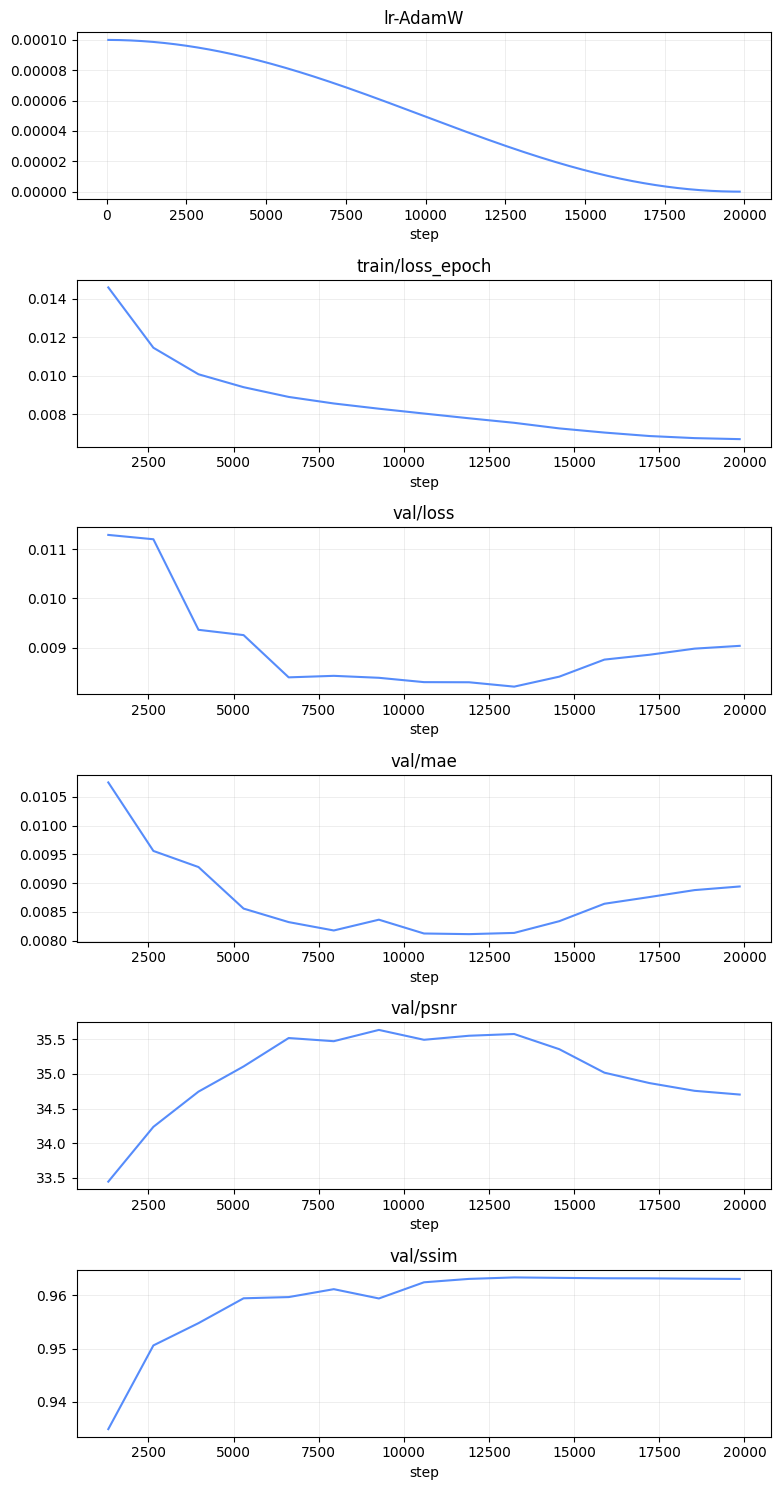

In [8]:
run_training_from_yaml(str(PROJECT_ROOT / "config" / "unet_2p5d.yaml"))

### 3.3 Train the 2.5D DDPM

Run the cell below to train DDPM with `config/ddpm_2p5d.yaml`.

This process may take about 15 mins.

DDPM learns a denoising objective and reconstructs images through iterative sampling. Compared with direct UNet regression, it is more flexible as a generative model, but it is also more sensitive to the noise schedule, number of sampling steps, and validation-time sampling settings.

Seed set to 24
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\jialin-li\.conda\envs\mri_sr\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory E:\MRI_SR_Tutorial\checkpoints\DDPM_2p5d exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=15` reached.


[DDPM_2p5d] best checkpoint: E:\MRI_SR_Tutorial\checkpoints\DDPM_2p5d\epoch_012_val_loss_0.0011.ckpt


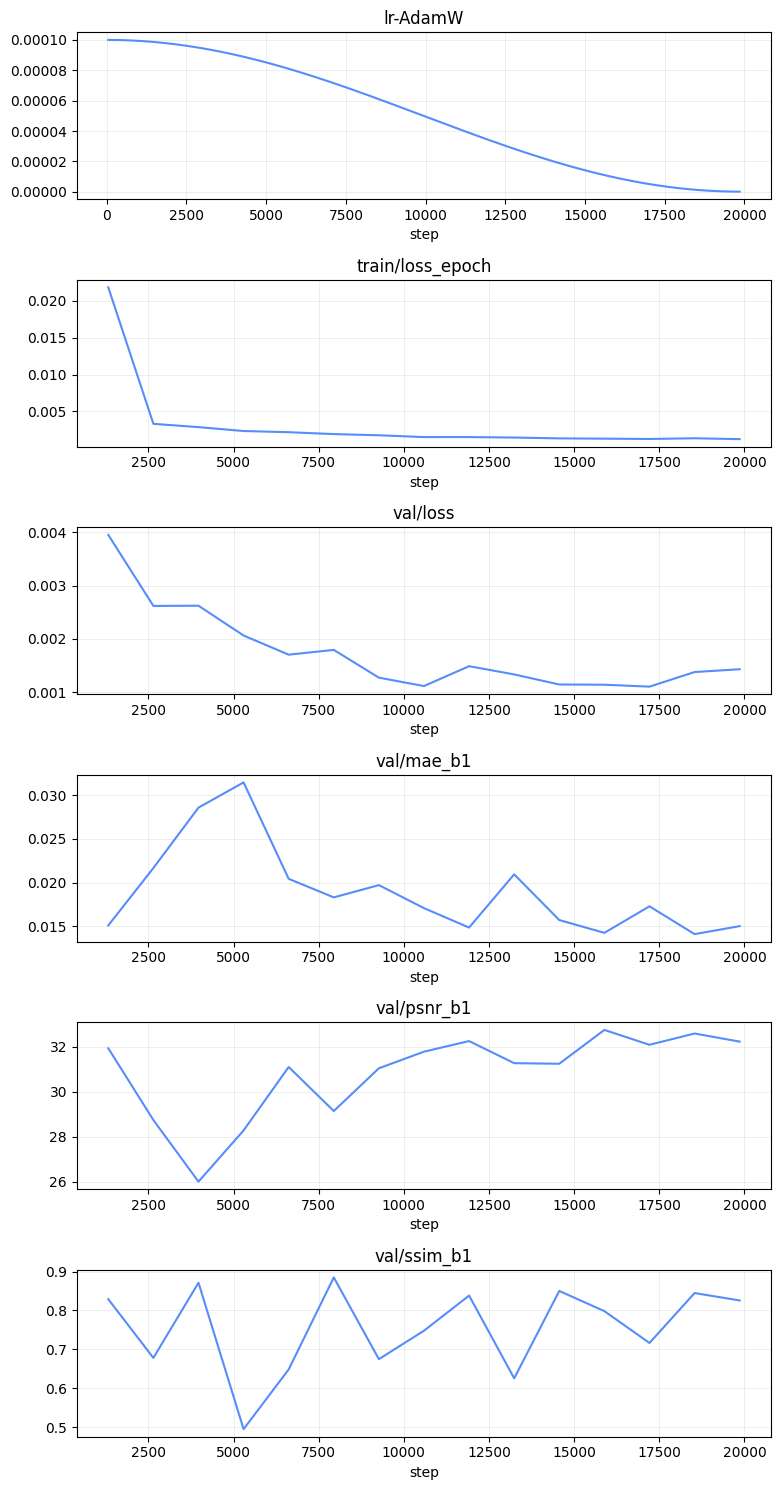

In [9]:
run_training_from_yaml(str(PROJECT_ROOT / "config" / "ddpm_2p5d.yaml"))

### 3.4 Train the 2.5D Flow Matching

Run the cell below to train Flow Matching with `config/fm_2p5d.yaml`.

This process may take about 15 mins.

Flow Matching learns a velocity field that transforms noise into the target residual through ODE-style sampling. It keeps the iterative generative formulation while usually requiring fewer sampling steps than conventional diffusion in this tutorial setup.

Seed set to 24
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\jialin-li\.conda\envs\mri_sr\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory E:\MRI_SR_Tutorial\checkpoints\FlowMatching_2p5d exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


Output()

`Trainer.fit` stopped: `max_epochs=15` reached.


[FlowMatching_2p5d] best checkpoint: E:\MRI_SR_Tutorial\checkpoints\FlowMatching_2p5d\epoch_014_val_loss_0.0096.ckpt


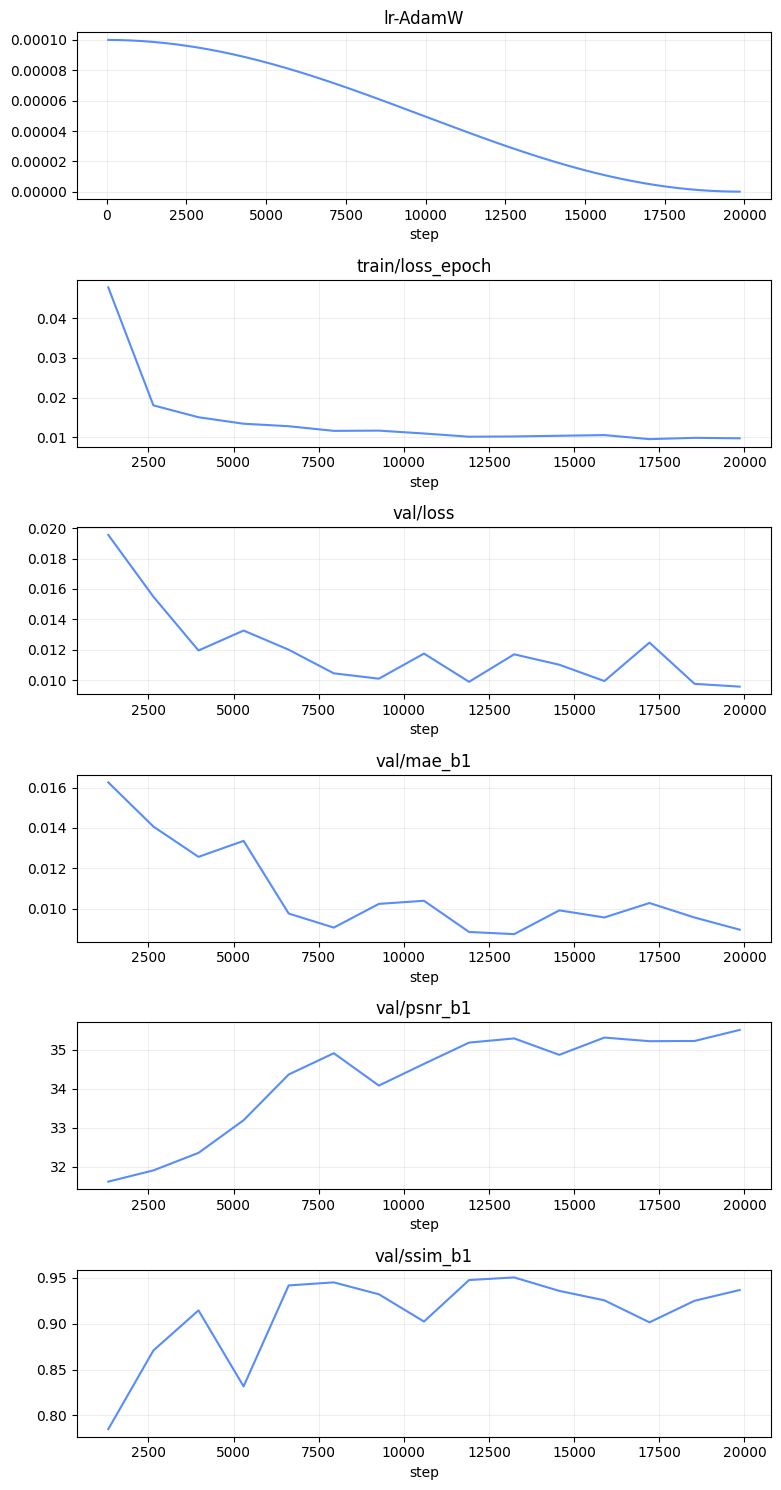

In [10]:
run_training_from_yaml(str(PROJECT_ROOT / "config" / "fm_2p5d.yaml"))